In [1]:
import sys
from pathlib import Path
# Make the repo root importable regardless of CWD or machine: walk up from the
# working dir until we hit a repo marker, then put that dir on sys.path.
_start = Path.cwd()
_root = next((p for p in (_start, *_start.parents)
              if (p / ".git").exists() or (p / "setup.py").exists()), _start)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
from metab_processing.metab_travlr_config import DATA_DIR


PROJECT = 'Alexi_UC_Spliced'
PROJECT_DIR = f'{DATA_DIR}/{PROJECT}'

In [2]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# This is for loading the coefficients into the adata, which requires spacetravlr to be installed (or at least some of its required arrays)

# adata = sc.read_h5ad(f'{DATA_DIR}/adata.h5ad')
# adata

# from metab_processing.SpaceTravLR import beta_analysis

# betadata_dir = f'{DATA_DIR}/spacetravlr_output/betadata'
# beta_analysis.betas_to_adata(adata, betadata_dir, group=None)
# print(adata)
# adata.write_h5ad(f"{DATA_DIR}/spacetravlr_adata.h5ad")
# del adata

In [4]:
PATIENT = '13473_HS4_UC'
SLICE = 1
DATASET_NAME = f'{PATIENT}-Slice_{SLICE}'
DATA_DIR = f'{PROJECT_DIR}/{DATASET_NAME}'
adata = sc.read_h5ad(f'{DATA_DIR}/spacetravlr_adata.h5ad')
adata

AnnData object with n_obs × n_vars = 12142 × 4736
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'orientation_cores', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'leiden', 'leiden_res_1_5', 'leiden_res_1_3', 'leiden_res_1_4', 'leiden_res_1_6', 'leiden_res_1_2', '25_06_11_ICI_5K_Compartments', '24_11_12_ICI_5K_Fine_annotations', '25_06_11_ICI_5K_Coarse_annotations', '240927_Condition', '25_06_11_Patient_ID_HS', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_c

/tmp/ipykernel_1489792/3727956402.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='25_06_11_ICI_5K_Coarse_annotations');


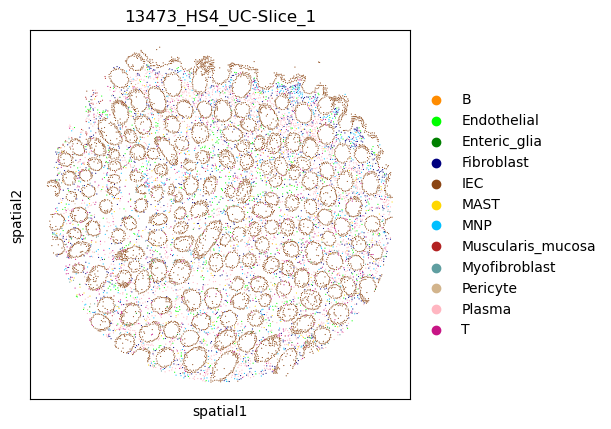

In [5]:
sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='25_06_11_ICI_5K_Coarse_annotations');

In [6]:
list(adata.uns['beta_modulators'])

['ATP1A1',
 'CD3E',
 'CD3G',
 'CD4',
 'CSF2',
 'CTLA4',
 'ENTPD1',
 'FOXP3',
 'HAVCR2',
 'HIF1A',
 'IL10',
 'IL17A',
 'IL17F',
 'IL2RA',
 'LAG3',
 'MAPK11',
 'MAPK12',
 'MAPK14',
 'MYC',
 'NDRG1',
 'PDCD1',
 'SCNN1A',
 'SCNN1G',
 'SGK1',
 'SLC5A1',
 'SLC9A3',
 'TBP',
 'TCF7',
 'TOX']

In [7]:
GENE = 'NDRG1'
adata.uns['beta_modulators'][GENE]

array(['AHR', 'AHRR', 'ARNT', 'ATF3', 'ATF4', 'BATF', 'BCL3', 'CREB1',
       'CTCF', 'CTCFL', 'E2F1', 'E2F3', 'E2F4', 'EGR2', 'EHF', 'ELK1',
       'ELK3', 'ELK4', 'EP300', 'ERG', 'ETS1', 'ETV1', 'ETV5', 'ETV6',
       'FEV', 'FLI1', 'FOSL1', 'FOXA1', 'FOXA2', 'FOXC1', 'FOXC2',
       'FOXE1', 'FOXE3', 'FOXI1', 'FOXJ2', 'FOXL2', 'FOXO1', 'FOXO3',
       'FOXO4', 'FOXP1', 'FOXP2', 'FOXP3', 'FOXP4', 'GATA1', 'GATA2',
       'HDAC2', 'HES1', 'HES4', 'HMGN3', 'HNF4A', 'IRF1', 'IRF4', 'JDP2',
       'JUN', 'KLF12', 'KLF14', 'KLF16', 'KLF4', 'KLF5', 'MAX', 'MEF2A',
       'MEF2C', 'NANOG', 'NFATC1', 'NFKB1', 'NR1I2', 'NR1I3', 'NR3C1',
       'NRF1', 'PAX1', 'PAX2', 'PAX5', 'PAX8', 'PBX3', 'POU5F1', 'PRDM1',
       'REST', 'RXRA', 'SALL4', 'SETDB1', 'SIN3A', 'SMAD1', 'SMARCA5',
       'SMARCB1', 'SMARCC1', 'SMC3', 'SOX18', 'SP1', 'SP3', 'SRF',
       'STAT1', 'STAT2', 'STAT3', 'TAF1', 'TAL1', 'TBP', 'TCF7L2',
       'TFAP2A', 'TFAP2B', 'TRIM28', 'TWIST1', 'TWIST2', 'WT1', 'YY1',
       'ZBTB

In [8]:
def plot_beta(adata, gene, modulator, tier, cell_types=None, spot_size=35):
    i = (adata.uns['beta_modulators'][gene] == modulator).argmax()
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    sub.obs['beta'] = sub.obsm[f'beta_{gene}'][:, i]
    sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
                  title=f'{gene} ~ {modulator} ({tier})')

/tmp/ipykernel_1489792/4168805372.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
/tmp/ipykernel_1489792/4168805372.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
/tmp/ipykernel_1489792/4168805372.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,


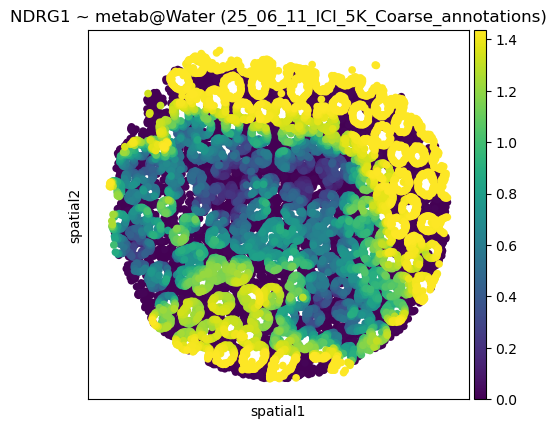

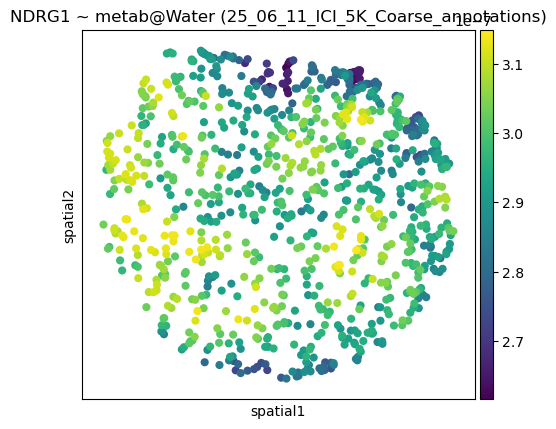

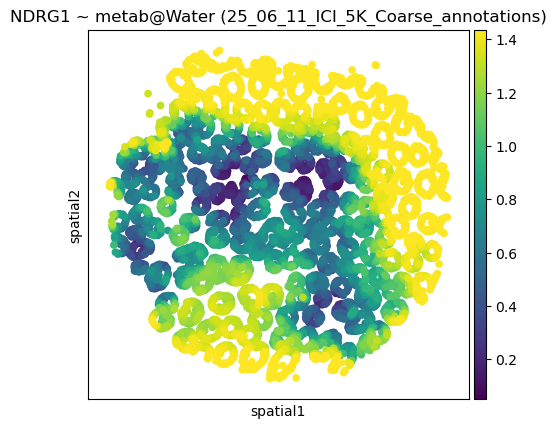

In [9]:
# gp = [m for m in adata.uns['beta_modulators'][GENE] if '@' in m][1]
gp = 'metab@Water'
plot_beta(adata, GENE, gp, '25_06_11_ICI_5K_Coarse_annotations')
plot_beta(adata, GENE, gp, '25_06_11_ICI_5K_Coarse_annotations', ['Fibroblast'])
plot_beta(adata, GENE, gp, '25_06_11_ICI_5K_Coarse_annotations', ['IEC'])

In [10]:
def get_betas_modulator(adata, gene, modulator, tier=None, cell_types=None):
    i = (adata.uns['beta_modulators'][gene] == modulator).argmax()
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    return sub.obsm[f'beta_{gene}'][:, i]

def agg_modulator(adata, gene, modulator, tier=None, cell_types=None):
    betas = get_betas_modulator(adata, gene, modulator, tier, cell_types)
    return np.mean(betas), np.std(betas)

agg_modulator(adata, GENE, 'NFKB1', '25_06_11_ICI_5K_Coarse_annotations', cell_types=['IEC'])
        

(np.float32(0.22868206), np.float32(0.15449575))

In [11]:
CELL_TYPE = 'IEC'
TIER = '25_06_11_ICI_5K_Coarse_annotations'
modulators = [x for x in adata.uns['beta_modulators'][GENE] if x.startswith('metab@')]
for modulator in modulators:
    print(modulator)

metab@(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3-yl-b-D-Glucopyranosiduronic acid|1b,3a,12a-Trihydroxy-5b-cholanoic acid|3-Sulfodeoxycholic acid|3alpha,7alpha-Dihydroxycoprostanic acid|3b-Hydroxy-5-cholenoic acid|Chenodeoxycholic acid|Chenodeoxycholic acid 3-sulfate|Coprocholic acid|Deoxycholic acid|Folinic acid|Glutathione|Glycochenodeoxycholate-3-sulfate|Hyodeoxycholic acid|Isoursodeoxycholic acid|Lithocholic acid|Sulfolithocholic acid|Trihydroxycoprostanoic acid|Ursocholic acid|Ursodeoxycholic acid|Ursodeoxycholic acid 3-sulfate|Varanic acid
metab@17a-Ethynylestradiol|3',4'-Dihydrodiol|4'-Hydroxydiclofenac|4-Hydroxycyclophosphamide|8-Hydroxycarvedilol|E-3179|Estriol|Glycerol|N-Desmethylcitalopram|N-Desmethyleletriptan|O-Deethylated candesartan
metab@2-Hydroxychlorpropamide
metab@25-Hydroxycholesterol
metab@4-ene-Valproic acid
metab@5-Hydroxyomeprazole
metab@Acetate
metab@Acetyl-L-Carnitine|Choline|Creatine|Dopamine|Histamine|Norepinephrine
metab@Adenosine triphosphate
metab@Amil

(array([ 889.,   41.,   20.,   15.,   12.,   13.,   16.,   27.,   37.,
        6708.]),
 array([-2.69679483e-02, -2.42711585e-02, -2.15743687e-02, -1.88775770e-02,
        -1.61807872e-02, -1.34839984e-02, -1.07872076e-02, -8.09041783e-03,
        -5.39362803e-03, -2.69683823e-03, -4.86456031e-08]),
 <BarContainer object of 10 artists>)

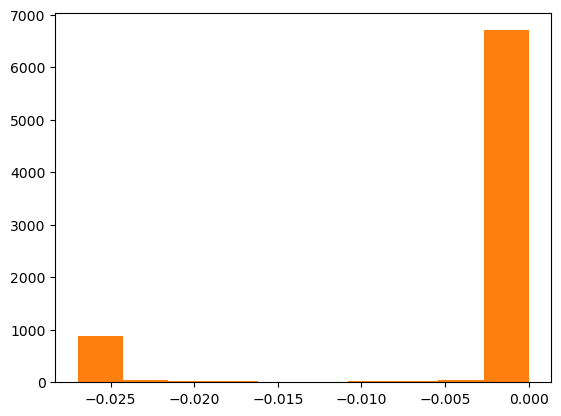

In [12]:
plt.hist(get_betas_modulator(adata, GENE, 'metab@Sodium', tier=TIER, cell_types=[CELL_TYPE]))
plt.hist(get_betas_modulator(adata, GENE, 'metab@Fatty Acid', tier=TIER, cell_types=[CELL_TYPE]))
# plt.hist(get_betas_modulator(adata, GENE, 'metab@Sodium', tier=TIER, cell_types=[CELL_TYPE]));
# plt.hist(get_betas_modulator(adata, GENE, 'metab@Sodium', tier=TIER, cell_types=[CELL_TYPE]));

In [13]:
harr_data_path = f'{DATA_DIR}/easy_download/harreman_outputs/[ccc_results][cell_com_df_m].csv'
harr_data = pd.read_csv(harr_data_path)
harr_data

,Unnamed: 0,Metabolite,C_p,Z,Z_pval,Z_FDR,C_np,pval_np,FDR_np,selected
0,0,"(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3...",6561.722476,3.819081,6.697476e-05,1.924002e-04,4565.770532,0.000999,0.001902,True
1,1,17a-Ethynylestradiol,1087.732313,0.863965,1.938036e-01,2.861772e-01,6204.135907,0.000999,0.001902,True
2,2,"1b,3a,12a-Trihydroxy-5b-cholanoic acid",6561.722476,3.819081,6.697476e-05,1.924002e-04,4565.770532,0.000999,0.001902,True
3,3,2-Hydroxychlorpropamide,983.805484,1.637178,5.079666e-02,9.787648e-02,8111.022841,0.000999,0.001902,True
4,4,25-Hydroxycholesterol,2345.571542,7.050788,8.895373e-13,9.369792e-12,2269.443120,0.002997,0.005571,True
...,...,...,...,...,...,...,...,...,...,...
153,153,Vitamin D3,2263.143662,6.803010,5.122786e-12,4.761178e-11,538.379201,0.000999,0.001902,True
154,154,Water,10068.549837,3.772934,8.066959e-05,2.276035e-04,130704.198027,0.000999,0.001902,True
155,155,Zinc,3985.656137,5.215775,9.152535e-08,5.561925e-07,2995.874037,0.000999,0.001902,True
156,156,alpha-Ketoisovaleric acid,1084.573588,3.260228,5.566131e-04,1.395950e-03,2595.406559,0.000999,0.001902,True


In [14]:
def _modulator_members(modulator):
    """'metab@A|B|C' -> ['A', 'B', 'C'] (exact whole-metabolite names)."""
    name = modulator.split('@', 1)[1] if '@' in modulator else modulator
    return name.split('|')


def mean_abs_coeff(adata, TARGET_GENE, modulator):
    betas = np.nan_to_num(get_betas_modulator(adata, TARGET_GENE, modulator, TIER, [CELL_TYPE]))
    return np.mean(np.abs(betas)), np.std(betas)


def extract_betas(TARGET_GENE, adata):
    """One row per metabolite: avg |β|, β std, and both FDRs. Returns a DataFrame."""
    modulators = adata.uns['beta_modulators'][TARGET_GENE]
    rows = []

    for metab in harr_data['Metabolite']:
        # EXACT membership, not substring: 'Adenosine' no longer matches
        # 'Adenosine triphosphate' or 'Adenosine diphosphate ribose'.
        match = [m for m in modulators if metab in _modulator_members(m)]

        if len(match) > 1:
            print(f"WARNING: {metab} matched multiple modulators: {match}")
            continue
        elif len(match) == 0:
            avg_coeff, std_coeff = 0.0, np.nan
        else:
            avg_coeff, std_coeff = mean_abs_coeff(adata, TARGET_GENE, match[0])

        h = harr_data.loc[harr_data['Metabolite'] == metab].iloc[0]
        rows.append({
            'metabolite': metab,
            'avg_coeff': avg_coeff,
            'std_coeff': std_coeff,
            'FDR_np': float(h['FDR_np']),
            'Z_FDR': float(h['Z_FDR']),
        })

    return pd.DataFrame(rows)


def plot_betas(df, fdr_col='Z_FDR', TARGET_GENE='', ax=None,
               labels=True, xlim=None, ylim=None):
    """Scatter avg |β| vs -log10(FDR). Set labels=False to hide text;
    pass xlim/ylim tuples to zoom."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    x = df['avg_coeff'].to_numpy()
    y = -np.log10(df[fdr_col].to_numpy())

    ax.s

fdr_vs_bata_df = extract_betas('CD3E', adata)

In [15]:
def extract_betas_all(target_genes, adata):
    """{gene: DataFrame} — one extract_betas result per target gene."""
    return {gene: extract_betas(gene, adata) for gene in target_genes}


def plot_betas_grid(dfs, fdr_col='Z_FDR', labels=False, ncols=3,
                    xlim=None, ylim=None, figsize=None):
    """Plot every gene's df in a grid. `dfs` is the {gene: DataFrame} dict."""
    genes = list(dfs)
    ncols = min(ncols, len(genes))
    nrows = -(-len(genes) // ncols)  # ceil
    if figsize is None:
        figsize = (5 * ncols, 4 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    for ax, gene in zip(axes, genes):
        plot_betas(dfs[gene], fdr_col=fdr_col, TARGET_GENE=gene, ax=ax,
                   labels=labels, xlim=xlim, ylim=ylim)

    for ax in axes[len(genes):]:  # hide unused panels
        ax.axis('off')

    fig.tight_layout()
    return fig, axes

genes = list(adata.uns['beta_modulators'])
dfs = extract_betas_all(genes, adata)

In [20]:
NDRG1_df = dfs[GENE]
NDRG1_df

,metabolite,avg_coeff,std_coeff,FDR_np,Z_FDR
0,"(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3...",5.630703e-04,8.217793e-05,0.001902,1.924002e-04
1,17a-Ethynylestradiol,1.004591e-02,3.423900e-03,0.001902,2.861772e-01
2,"1b,3a,12a-Trihydroxy-5b-cholanoic acid",5.630703e-04,8.217793e-05,0.001902,1.924002e-04
3,2-Hydroxychlorpropamide,1.537748e-02,4.343918e-03,0.001902,9.787648e-02
4,25-Hydroxycholesterol,3.534478e-05,1.400429e-05,0.005571,9.369792e-12
...,...,...,...,...,...
153,Vitamin D3,0.000000e+00,NaN,0.001902,4.761178e-11
154,Water,9.532682e-01,4.156162e-01,0.001902,2.276035e-04
155,Zinc,6.212905e-08,1.572782e-08,0.001902,5.561925e-07
156,alpha-Ketoisovaleric acid,4.840450e-04,1.919141e-04,0.001902,1.395950e-03


(array([139.,   4.,   2.,   3.,   3.,   1.,   1.,   1.,   0.,   0.,   0.,
          0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([0.        , 0.01214333, 0.02428667, 0.03643   , 0.04857333,
        0.06071666, 0.07286   , 0.08500333, 0.09714666, 0.10929   ,
        0.12143333, 0.13357666, 0.14572   , 0.15786333, 0.17000666,
        0.18214999, 0.19429333, 0.20643666, 0.21857999, 0.23072333,
        0.24286666, 0.25500999, 0.26715333, 0.

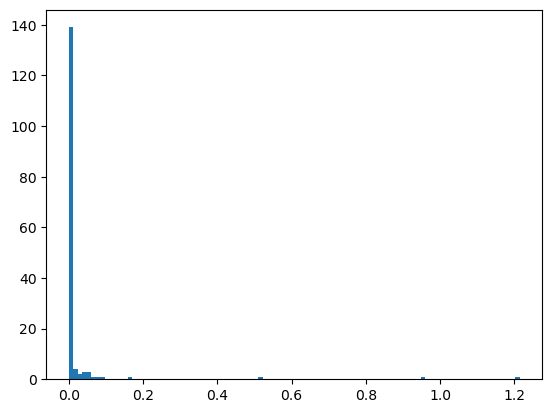

In [26]:
plt.hist(NDRG1_df.loc[:, 'avg_coeff'], bins=100)